# F3 — Analyse Exploratoire des Offres d'Emploi au Sénégal
**Projet** : Analyse des Offres d'Emploi au Sénégal — Volkeno

**Objectif** : Explorer et visualiser les données nettoyées

**Analyses** :
- Chargement et exploration des données
- Répartition géographique des offres par ville
- Évolution mensuelle du nombre d'offres
- Répartition par type de contrat

## Import des bibliothèques

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Style global
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print('Bibliothèques importées !')

Bibliothèques importées !


## 📂 Chargement et exploration des données

In [2]:
import os

# Chemin absolu vers le fichier
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
FILE     = os.path.join(BASE_DIR, 'data', 'cleaned', 'offres_emploi_senegal_cleaned.csv')

df = pd.read_csv(FILE, encoding='utf-8-sig')

print(f'-- Dimensions : {df.shape[0]} offres x {df.shape[1]} colonnes')
print(f'\nColonnes : {df.columns.tolist()}')
print(f'\nAperçu :')
display(df.head(5))

print(f'\n-- Valeurs manquantes :')
for col in df.columns:
    n = (df[col] == 'Non précisé').sum()
    pct = round(n / len(df) * 100, 1)
    print(f'  {col:25} → {n:4} Non précisé ({pct}%)')

-- Dimensions : 3332 offres x 24 colonnes

Colonnes : ['Intitulé du poste', 'Entreprise', 'Ville', 'Type de contrat', 'Date de publication', 'Compétences demandées', 'Intitulé du poste original', 'Niveau', 'Catégorie', 'Comp_anglais', 'Comp_francais', 'Comp_gestion', 'Comp_communication', 'Comp_bureautique', 'Comp_comptabilité', 'Comp_vente', 'Comp_technique', 'Comp_leadership', 'Comp_informatique', 'Comp_réseau', 'Comp_sécurité', 'Comp_qualité', 'Comp_marketing', 'Comp_logistique']

Aperçu :


,Intitulé du poste,Entreprise,Ville,Type de contrat,Date de publication,Compétences demandées,Intitulé du poste original,Niveau,Catégorie,Comp_anglais,...,Comp_comptabilité,Comp_vente,Comp_technique,Comp_leadership,Comp_informatique,Comp_réseau,Comp_sécurité,Comp_qualité,Comp_marketing,Comp_logistique
0,Superviseur Tracking & Monitoring,La Laiterie du Berger,Thiès,CDD,Publié le 13 mars 2026,Assurer le suivi en temps réel des opérations ...,Superviseur Tracking & Monitoring,Responsable,Informatique / IT,1,...,0,0,0,1,0,0,1,0,0,1
1,Superviseur Maintenance Parc – Transport Primaire,La Laiterie du Berger,Thiès,CDD,Publié le 13 mars 2026,Assurer le suivi technique et la maintenance d...,Superviseur Maintenance Parc – Transport Primaire,Responsable,Logistique / Transport,1,...,0,0,1,1,0,0,0,1,0,1
2,Lead Transport & Maintenance (DS/TP),La Laiterie du Berger,Thiès,CDD,Publié le 13 mars 2026,Assurer le pilotage stratégique et opérationne...,Lead Transport & Maintenance (DS/TP),Senior,Logistique / Transport,1,...,0,0,1,1,0,0,0,0,0,1
3,Consultant,Développement International Desjardins,Dakar,CDD,Publié le 13 mars 2026,Mettre en place les outils de collecte (fiches...,Consultant Technique Suivi-Évaluation,Non précisé,Non précisé,0,...,0,0,0,1,0,0,1,1,0,0
4,Chef de Projet,GBG,Dakar,CDD,Publié le 13 mars 2026,Gestion quotidienne des opérations sur le site...,Key Account Manager / Project Manager,Responsable,Direction,1,...,0,0,0,1,0,0,1,1,0,0



-- Valeurs manquantes :
  Intitulé du poste         →    0 Non précisé (0.0%)
  Entreprise                →    0 Non précisé (0.0%)
  Ville                     →   19 Non précisé (0.6%)
  Type de contrat           →   44 Non précisé (1.3%)
  Date de publication       →    0 Non précisé (0.0%)
  Compétences demandées     →    2 Non précisé (0.1%)
  Intitulé du poste original →    0 Non précisé (0.0%)
  Niveau                    → 2265 Non précisé (68.0%)
  Catégorie                 →  844 Non précisé (25.3%)
  Comp_anglais              →    0 Non précisé (0.0%)
  Comp_francais             →    0 Non précisé (0.0%)
  Comp_gestion              →    0 Non précisé (0.0%)
  Comp_communication        →    0 Non précisé (0.0%)
  Comp_bureautique          →    0 Non précisé (0.0%)
  Comp_comptabilité         →    0 Non précisé (0.0%)
  Comp_vente                →    0 Non précisé (0.0%)
  Comp_technique            →    0 Non précisé (0.0%)
  Comp_leadership           →    0 Non précisé (0.0%)


## Parsing des dates

In [3]:
MOIS = {
    'janvier': '01', 'février': '02', 'mars': '03',
    'avril': '04', 'mai': '05', 'juin': '06',
    'juillet': '07', 'août': '08', 'septembre': '09',
    'octobre': '10', 'novembre': '11', 'décembre': '12',
    'janv.': '01', 'févr.': '02', 'avr.': '04',
    'juil.': '07', 'sept.': '09', 'oct.': '10',
    'nov.': '11', 'déc.': '12',
}

def parser_date(date_str):
    if pd.isna(date_str) or date_str == 'Non précisé':
        return pd.NaT
    date_str = str(date_str).strip().lower()
    for mois_fr, mois_num in MOIS.items():
        if mois_fr in date_str:
            date_str = date_str.replace(mois_fr, mois_num)
            break
    try:
        return pd.to_datetime(date_str, dayfirst=True)
    except:
        return pd.NaT

df['Date parsed'] = df['Date de publication'].apply(parser_date)
df['Mois']        = df['Date parsed'].dt.to_period('M')

print(f'-- Dates parsées : {df["Date parsed"].notna().sum()} / {len(df)}')
print(f'   Période : {df["Date parsed"].min().date()} → {df["Date parsed"].max().date()}')

-- Dates parsées : 3315 / 3332
   Période : 2024-07-01 → 2026-03-13


## Répartition géographique des offres par ville

C:\Users\HP\AppData\Local\Temp\ipykernel_6088\1372450433.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=villes, x='Ville', y="Nombre d'offres", palette='Blues_d', ax=ax)


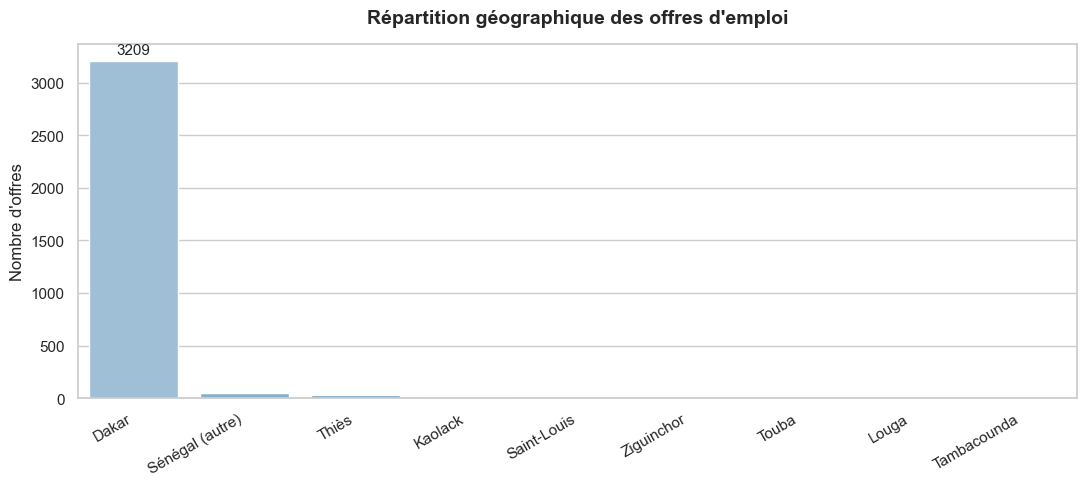

-- Graphique sauvegardé : repartition_villes.png


In [4]:
villes = (
    df[df['Ville'] != 'Non précisé']['Ville']
    .value_counts()
    .head(10)
    .reset_index()
)
villes.columns = ['Ville', "Nombre d'offres"]

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=villes, x='Ville', y="Nombre d'offres", palette='Blues_d', ax=ax)
ax.set_title("Répartition géographique des offres d'emploi", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel("Nombre d'offres")
ax.bar_label(ax.containers[0], fmt='%d', padding=3)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('repartition_villes.png', dpi=150, bbox_inches='tight')
plt.show()
print('-- Graphique sauvegardé : repartition_villes.png')

## Évolution mensuelle du nombre d'offres

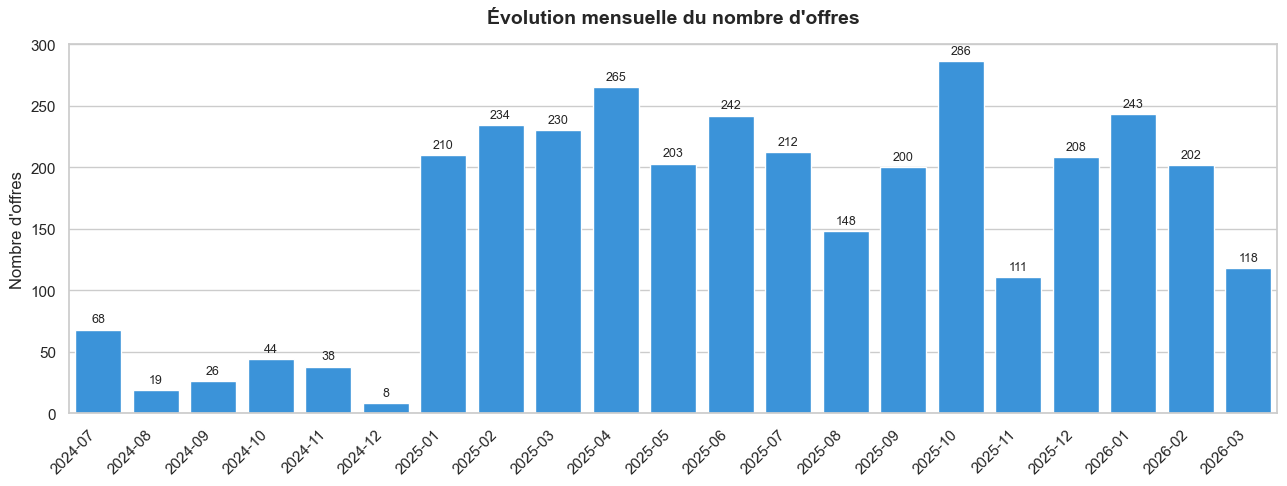

Graphique sauvegardé : evolution_mensuelle.png


In [5]:
evolution = (
    df[df['Mois'].notna()]
    .groupby('Mois')
    .size()
    .reset_index(name="Nombre d'offres")
    .sort_values('Mois')
)
evolution['Mois str'] = evolution['Mois'].astype(str)

fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=evolution, x='Mois str', y="Nombre d'offres", color='#2196F3', ax=ax)
ax.set_title("Évolution mensuelle du nombre d'offres", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel("Nombre d'offres")
ax.bar_label(ax.containers[0], fmt='%d', padding=3, fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('evolution_mensuelle.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : evolution_mensuelle.png')

## Répartition par type de contrat

C:\Users\HP\AppData\Local\Temp\ipykernel_6088\1055385291.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contrats, x='Type de contrat', y="Nombre d'offres", palette='Set2', ax=ax)


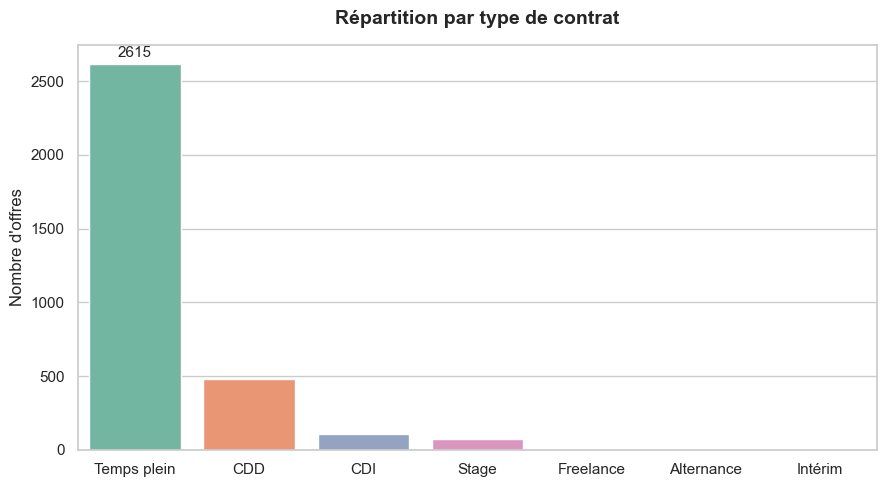

Graphique sauvegardé : repartition_contrats.png


In [6]:
contrats = (
    df[df['Type de contrat'] != 'Non précisé']['Type de contrat']
    .value_counts()
    .reset_index()
)
contrats.columns = ['Type de contrat', "Nombre d'offres"]

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=contrats, x='Type de contrat', y="Nombre d'offres", palette='Set2', ax=ax)
ax.set_title('Répartition par type de contrat', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel("Nombre d'offres")
ax.bar_label(ax.containers[0], fmt='%d', padding=3)
plt.tight_layout()
plt.savefig('repartition_contrats.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : repartition_contrats.png')